#Exercício K-Means

##Escolha de Locais para Centros de Distribuição com k-Means

Uma empresa de logística deseja instalar centros de distribuição em uma região para atender 1000 clientes de forma eficiente. O objetivo é minimizar a distância total de transporte entre os centros e os clientes.

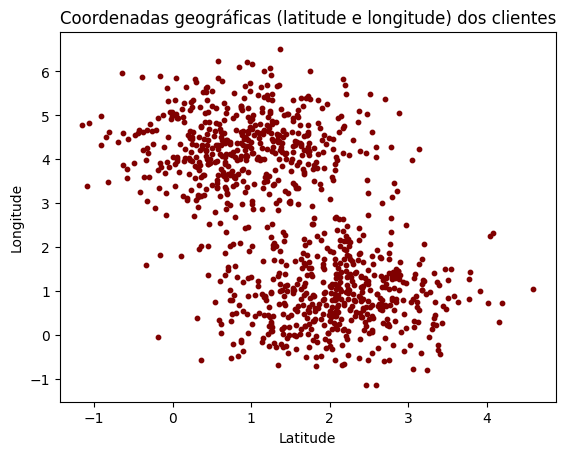

In [43]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# Gerar dados fictícios (1000 clientes, 2 clusters naturais)

clientes, _ = make_blobs(n_samples=1000, centers=2, cluster_std=0.8, random_state=0)
df = pd.DataFrame(clientes, columns=['latitude', 'longitude'])


# Plotar clientes e centroides

plt.scatter(df['latitude'], df['longitude'], s=10, c="maroon")
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.title('Coordenadas geográficas (latitude e longitude) dos clientes')
plt.show()

2. Qual é a quantidade correta de centros de distribuição para minimizar a distância entre os clientes e os centros?
OBS.: Você pode usar o método do cotovelo para descobrir a quantidade de centros de distribuição.

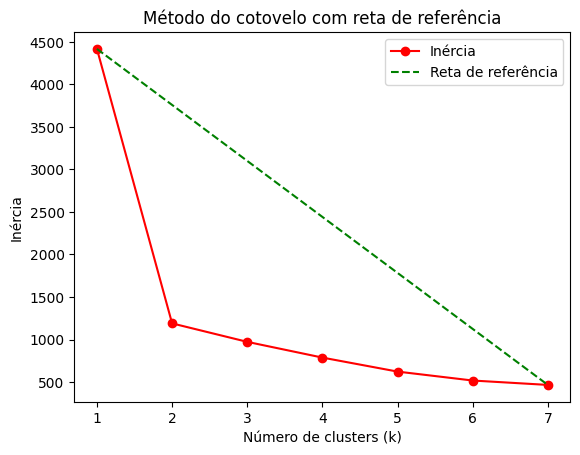

In [23]:
from sklearn.cluster import KMeans
seed = 42
inercia = []
numMaxClusters = 7
for k in range (1, numMaxClusters+1):
  kmeans = KMeans(n_clusters=k, random_state=seed)
  kmeans.fit(clientes)
  inercia.append(kmeans.inertia_)

k_values = range(1, numMaxClusters+1)
plt.plot(k_values, inercia, 'ro-', label='Inércia')

# Definir extremos (primeiro e último pontos)
primeiro_ponto = (1, inercia[0])
ultimo_ponto = (numMaxClusters, inercia[-1])

# Equação da reta entre os extremos (y = a*x + b)
x = np.array([1, numMaxClusters])
y = np.array([inercia[0], inercia[-1]])
a, b = np.polyfit(x, y, 1)

plt.plot(x, a*x + b, 'g--', label='Reta de referência')

plt.xlabel('Número de clusters (k)')
plt.ylabel('Inércia')
plt.title('Método do cotovelo com reta de referência')
plt.legend()
plt.show()

Número de clusters escolhido: 2


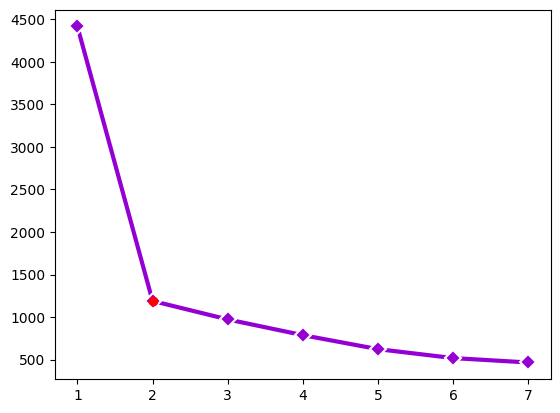

In [47]:
dists = []
for k in range(1, numMaxClusters+1):
  reta_y = a * k + b
  dist = abs(inercia[k-1] - reta_y)
  dists.append(dist)

k_escolhido = np.argmax(dists) + 1
print(f'Número de clusters escolhido: {k_escolhido}')
plt.plot(k_values, inercia, marker='D', linestyle='-', color='darkviolet',
         linewidth=3, markersize=8, markeredgecolor='white', markeredgewidth=1.5, label='Inércia')

plt.plot(k_escolhido, inercia[k_escolhido-1], 'ro', label='k escolhido')

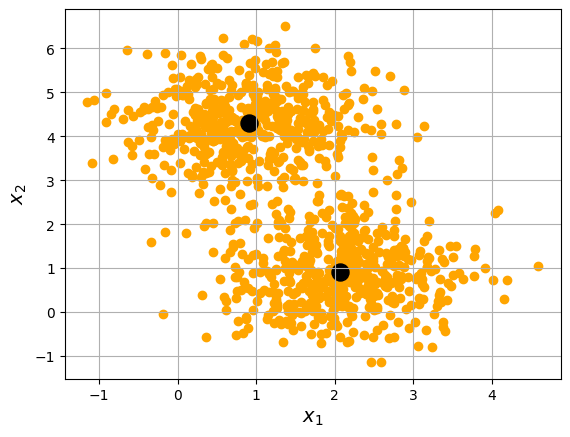

In [32]:
kmeans = KMeans(n_clusters=k_escolhido, random_state=seed)
kmeans.fit(clientes)

plt.scatter(clientes[:,0], clientes[:,1], c="orange")
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=150, c='black')
plt.xlabel('$x_1$', fontsize=14)
plt.ylabel('$x_2$', fontsize=14)
plt.grid()
plt.show()

**Resposta**: A quantidade correta de centros deve ser igual a 2.